# Wikimedia

In [1]:
import requests

url = "https://wikimedia.org/api/rest_v1/metrics/pageviews/top-per-country/CA/all-access/2026/08/01"
resp = requests.get(url, headers={"User-Agent": "zitygeist-exploration (personal project)"})
print(resp.status_code)
data = resp.json()

200


## Raw response shape

In [2]:
data.keys()

dict_keys(['items'])

In [3]:
data['items'][0]['articles'][0]

{'article': 'Main_Page',
 'project': 'en.wikipedia',
 'views_ceil': 169000,
 'rank': 1}

## Noise filtering

Some ranked "articles" aren't content — search pages, main pages, portals. Need a rule to tell those apart from real articles.

### Naive colon filter — false positives

First instinct: filter anything with a colon (`Special:Search`, `Wikipedia:...`). Doesn't work — real titles have colons too (`Spider-Man:_Brand_New_Day`).

In [4]:
for item in data['items'][0]['articles']:
    if ":" in item['article']:
        print(item['article'], item['rank'])

Spider-Man:_Brand_New_Day 2
Special:Search 3
Wikipedia:Featured_pictures 4
Wikipédia:Accueil_principal 7
UFC_Fight_Night:_Medić_vs._Rodriguez 22
Spider-Man:_No_Way_Home 28
Wikipedia:首页 29
Portal:Current_events 39
Avengers:_Doomsday 54
Spécial:Recherche 67
Spider-Man:_Homecoming 68
Wiktionary:Main_Page 70
Spider-Man:_Far_From_Home 92
Special:Search 97
Marvel_Cinematic_Universe:_Phase_Six 114
Avatar_Aang:_The_Last_Airbender 120
Special:UrlShortener 125
Batman:_Caped_Crusader 126
Avengers:_Secret_Wars 208


### Namespace-driven filter

Better rule: ask each project's own API what its real namespace names and main page title are, instead of guessing. A colon prefix only counts as noise if it matches a *real* namespace name for that specific project (namespace names are localized per language, e.g. `Wikipédia:` vs `Wikipedia:`).

Logic lives in `wikimedia_noise.py` (next to this notebook) so it's reusable, not copy-pasted per notebook.

In [5]:
projects = sorted({a['project'] for a in data['items'][0]['articles']})
projects

['commons.wikimedia',
 'en.wikipedia',
 'en.wiktionary',
 'fr.wikipedia',
 'wikitech.wikimedia',
 'zh.wikipedia',
 'zu.wikibooks']

In [6]:
from wikimedia_noise import fetch_siteinfo, is_noise

for p in projects:
    fetch_siteinfo(p)  # warm cache, so we can inspect below

{p: fetch_siteinfo(p)['mainpage'] for p in projects}

{'commons.wikimedia': 'Main_Page',
 'en.wikipedia': 'Main_Page',
 'en.wiktionary': 'Wiktionary:Main_Page',
 'fr.wikipedia': 'Wikipédia:Accueil_principal',
 'wikitech.wikimedia': 'Main_Page',
 'zh.wikipedia': 'Wikipedia:首页',
 'zu.wikibooks': 'Ikhasi_Elikhulu'}

In [7]:
articles = data['items'][0]['articles']
noise = [a for a in articles if is_noise(a['article'], a['project'])]
kept = [a for a in articles if not is_noise(a['article'], a['project'])]

print(f"{len(articles)} total -> {len(noise)} noise, {len(kept)} kept")
for a in noise:
    print(' ', a['rank'], a['project'], a['article'])

220 total -> 12 noise, 208 kept
  1 en.wikipedia Main_Page
  3 en.wikipedia Special:Search
  4 en.wikipedia Wikipedia:Featured_pictures
  7 fr.wikipedia Wikipédia:Accueil_principal
  15 wikitech.wikimedia Main_Page
  29 zh.wikipedia Wikipedia:首页
  39 en.wikipedia Portal:Current_events
  44 commons.wikimedia Main_Page
  67 fr.wikipedia Spécial:Recherche
  70 en.wiktionary Wiktionary:Main_Page
  97 zu.wikibooks Special:Search
  125 zu.wikibooks Special:UrlShortener


### Remaining edge cases — not caught by the namespace rule

`Deaths_in_2026` (rank 13) is a real article, so the namespace rule correctly keeps it — but it's the same kind of structurally-recurring, low-signal page the insights doc flagged. This isn't a namespace problem, it's a title-pattern problem, so it needs its own small rule.

In [8]:
import re

RECURRING_PATTERNS = [
    re.compile(r"^Deaths_in_\d{4}$"),
]

def is_recurring(article: str) -> bool:
    return any(p.match(article) for p in RECURRING_PATTERNS)

[a['article'] for a in kept if is_recurring(a['article'])]

['Deaths_in_2026']

## Comparing across countries — US, Mexico

Same date, same namespace-driven filter. Checking: does the filter hold up outside Canada, and do we see the expected mix of shared global topics + locally distinct ones?

In [9]:
from wikimedia_noise import USER_AGENT


def fetch_top_per_country(country: str, date: str) -> list[dict]:
    year, month, day = date.split("-")
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/top-per-country/{country}/all-access/{year}/{month}/{day}"
    resp = requests.get(url, headers={"User-Agent": USER_AGENT})
    resp.raise_for_status()
    return resp.json()["items"][0]["articles"]

In [10]:
DATE = "2026-08-01"

by_country = {
    "CA": data["items"][0]["articles"],  # already fetched above
    "US": fetch_top_per_country("US", DATE),
    "MX": fetch_top_per_country("MX", DATE),
}
{c: len(a) for c, a in by_country.items()}

{'CA': 220, 'US': 1000, 'MX': 110}

In [11]:
filtered = {}
for country, articles in by_country.items():
    noise = [a for a in articles if is_noise(a["article"], a["project"])]
    kept = [a for a in articles if not is_noise(a["article"], a["project"])]
    filtered[country] = {"noise": noise, "kept": kept}
    print(f"{country}: {len(articles)} total -> {len(noise)} noise, {len(kept)} kept")

CA: 220 total -> 12 noise, 208 kept
US: 1000 total -> 91 noise, 909 kept
MX: 110 total -> 39 noise, 71 kept


### Shared vs. local — does Mexico actually look different?

Comparing kept titles across the three countries: what's common to all (likely global attention) vs. unique to one (locally distinct).

In [12]:
titles = {c: {a["article"] for a in filtered[c]["kept"]} for c in by_country}

shared_all_three = titles["CA"] & titles["US"] & titles["MX"]
print(f"shared across all 3: {len(shared_all_three)}")
print(sorted(shared_all_three))

for c in by_country:
    only_c = titles[c] - set().union(*(titles[o] for o in titles if o != c))
    print(f"\nunique to {c}: {len(only_c)}")
    print(sorted(only_c)[:15])

shared across all 3: 20
['Anne_Hathaway', 'Avengers:_Doomsday', 'Ceuta', 'Christopher_Nolan', 'Cristiano_Ronaldo', 'Erling_Haaland', 'Franco_Baresi', 'Gianni_Infantino', 'Jean_Grey', 'Nirmal_Purja', 'Sadie_Sink', 'Sid_Wilson', 'Spider-Man:_Brand_New_Day', 'Spider-Man:_Homecoming', 'Spider-Man:_No_Way_Home', 'SummerSlam_(2026)', 'The_Odyssey_(2026_film)', 'Tom_Holland', 'YouTube', 'Zendaya']

unique to CA: 21
['Angine_de_poitrine_(groupe)', 'Arthur_Griffiths_(businessman)', 'Attentat_de_Lockerbie', 'Canada', 'Caribana', 'Civic_Holiday', 'Commonwealth_Games', 'Dylan_Cease', 'Edmonton_tornado', 'Italian_training_ship_Amerigo_Vespucci', 'Jeffrey_Arenburg', 'Kevin_Gausman', 'Lars_Nootbaar', 'Leylah_Fernandez', 'Luis_Urías']

unique to US: 721
['14_Peaks:_Nothing_Is_Impossible', '2024_Apalachee_High_School_shooting', '2024_United_States_presidential_election', '2026_CONCACAF_U-20_Championship', '2026_Kumamoto_earthquake', '2026_United_States_Senate_election_in_Michigan', '2026_United_States_

### Noise ratio isn't really about the country

Noise share: CA ~5% (12/220), US ~9% (91/1000), MX ~35% (39/110). MX's noise is almost entirely `Special:Search`/`Special:RecentChanges` hits across dozens of small, geographically-irrelevant wikis (Fijian, Cornish, Hausa, Rwandan, Slovak...) — reads like automated/bot traffic that evaded Wikipedia's bot filter, geolocated to Mexico via hosting/VPN infra rather than real readers.

It shows up in MX specifically *because* MX's total list is short (110 vs. US's 1000) — the list-length difference above isn't a fixed 1000-per-country constant, it looks like the API's confidence/threshold suppression for lower-traffic country-article pairs. In a short list, a fixed amount of background bot noise is a much bigger share; in the US the same noise floor exists but is buried under 900+ real articles.

**Takeaway**: list length itself is a per-country/day data-quality signal worth capturing as metadata, not just the noise-filtered count — a short list means both lower confidence and proportionally noisier.

Real signal still comes through clean either way — the 20 shared titles above skew global entertainment/sports (Avengers, Spider-Man, Ronaldo, Haaland), and each country's unique list is genuinely locally distinctive (MX: Copa Mundial 2026, Día de la Pachamama; CA: Caribana, Commonwealth Games) — the mix we were hoping to see.

## Are Mexico's noise pages human or bot traffic?

The `per-article` pageviews endpoint splits views by `agent`: `user` / `spider` / `automated`. Caveat: this endpoint is **global, not country-scoped** — the public API doesn't expose country × agent together — so this can only be circumstantial evidence (does this page get real human traffic *at all*, anywhere), not direct proof about the Mexico-attributed hits specifically.

In [13]:
import time
from datetime import date as dt_date, timedelta
from urllib.parse import quote


def per_article_views(project: str, article: str, date: str, agent: str = "all-agents") -> int:
    d = dt_date.fromisoformat(date)
    start = d.strftime("%Y%m%d")
    end = (d + timedelta(days=1)).strftime("%Y%m%d")
    url = (
        f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
        f"{project}/all-access/{agent}/{quote(article, safe='')}/daily/{start}/{end}"
    )
    for attempt in range(5):
        r = requests.get(url, headers={"User-Agent": USER_AGENT})
        if r.status_code == 404:
            return 0
        if r.status_code == 429:
            time.sleep(int(r.headers.get("Retry-After", 2 ** attempt)))
            continue
        r.raise_for_status()
        items = r.json()["items"]
        return items[0]["views"] if items else 0
    raise RuntimeError(f"per-article views for {project}/{article} still rate-limited after retries")

In [14]:
import pandas as pd

# reasonable sample, not all 39 — evenly spread across the rank range
sample = filtered["MX"]["noise"][::4]

rows = []
for a in sample:
    total = per_article_views(a["project"], a["article"], DATE, "all-agents")
    user = per_article_views(a["project"], a["article"], DATE, "user")
    rows.append({
        "rank": a["rank"],
        "project": a["project"],
        "article": a["article"],
        "global_views_total": total,
        "global_views_user": user,
        "bot_share": round(1 - user / total, 2) if total else None,
    })

noise_df = pd.DataFrame(rows).sort_values("bot_share", ascending=False, na_position="last")
noise_df

,rank,project,article,global_views_total,global_views_user,bot_share
0,1,en.wikipedia,Main_Page,18000224,6818841,0.62
9,108,fr.wikibooks,Spécial:Recherche,151307,59753,0.61
2,24,en.wiktionary,Special:Search,141233,64561,0.54
6,60,ang.wikibooks,Syndrig:Search,152454,84494,0.45
7,84,wikidata,Special:Search,136884,75837,0.45
3,31,zgh.wikipedia,ⴰⵎⵥⵍⵉ:RecentChanges,246280,140819,0.43
5,55,sw.wikipedia,Maalum:MabadalikoyaKaribuni,170600,97001,0.43
8,93,szy.wikipedia,sazumaay:近期變更,112313,63663,0.43
1,10,en.wikipedia,Special:Search,972767,750135,0.23
4,49,gd.wikipedia,Sònraichte:RecentChanges,0,104728,NaN


In [15]:
print(f"median bot_share: {noise_df['bot_share'].median():.0%}")
print(f"pages with bot_share > 50%: {(noise_df['bot_share'] > 0.5).sum()} / {len(noise_df)}")
print(f"pages with global_views_total > 10,000: {(noise_df['global_views_total'] > 10_000).sum()} / {len(noise_df)}")

median bot_share: 45%
pages with bot_share > 50%: 3 / 10
pages with global_views_total > 10,000: 9 / 10


## Wikidata Q-id resolution

The project's join key: the same real-world entity should resolve to the same Q-id across sources (GDELT, TMDB, Wikipedia). Test: resolve one title to its Q-id via that project's own API — `action=query&prop=pageprops`, `wikibase_item` property — same per-project pattern already used for the noise filter's siteinfo calls.

Start with one known-shared title: `Cristiano_Ronaldo` on `en.wikipedia`.

In [16]:
r = requests.get(
    "https://en.wikipedia.org/w/api.php",
    params={
        "action": "query",
        "prop": "pageprops",
        "ppprop": "wikibase_item",
        "titles": "Cristiano_Ronaldo",
        "format": "json",
    },
    headers={"User-Agent": USER_AGENT},
)
print(r.status_code)
r.json()

200


{'batchcomplete': '',
 'query': {'normalized': [{'from': 'Cristiano_Ronaldo',
    'to': 'Cristiano Ronaldo'}],
  'pages': {'623737': {'pageid': 623737,
    'ns': 0,
    'title': 'Cristiano Ronaldo',
    'pageprops': {'wikibase_item': 'Q11571'}}}}}

### Cross-language check — Spanish Wikipedia

Note: the "shared across CA/US/MX" set earlier was built from article title strings only, discarding `project` — so it doesn't actually prove any cross-language viewing happened (all three could just be reading `en.wikipedia`'s article). This is the real test: does `es.wikipedia`'s own article for Ronaldo resolve to the same `Q11571`?

In [17]:
r = requests.get(
    "https://es.wikipedia.org/w/api.php",
    params={
        "action": "query",
        "prop": "pageprops",
        "ppprop": "wikibase_item",
        "titles": "Cristiano_Ronaldo",
        "format": "json",
    },
    headers={"User-Agent": USER_AGENT},
)
print(r.status_code)
r.json()

200


{'batchcomplete': '',
 'query': {'normalized': [{'from': 'Cristiano_Ronaldo',
    'to': 'Cristiano Ronaldo'}],
  'pages': {'210682': {'pageid': 210682,
    'ns': 0,
    'title': 'Cristiano Ronaldo',
    'pageprops': {'wikibase_item': 'Q11571'}}}}}

**Confirmed**: `en.wikipedia` (pageid 623737) and `es.wikipedia` (pageid 210682) — two different pages — both resolve to `Q11571`. The join key works end to end, not just in theory.

### A reusable, batched resolver

One title per API call doesn't scale — a country's kept list can be hundreds of titles, and `action=query` rate-limits much tighter than the pageviews REST API (we already hit 429s on it twice this session, on the siteinfo calls). MediaWiki allows up to 50 titles per request, so `wikimedia_qid.py` batches instead of resolving one at a time. It also follows redirects (`redirects=1`) and normalization, and returns `None` for titles with no linked Wikidata item rather than raising.

Test at real scale: resolve Canada's full 208-title kept list.

In [18]:
from collections import defaultdict

from wikimedia_qid import resolve_qids

by_project = defaultdict(list)
for a in filtered["CA"]["kept"]:
    by_project[a["project"]].append(a["article"])

qids = {}
n_requests = 0
for project, article_titles in by_project.items():
    qids[project] = resolve_qids(project, article_titles)
    n_requests += -(-len(article_titles) // 50)  # ceil division, matches batch count

resolved = sum(1 for p in qids.values() for q in p.values() if q)
total = sum(len(p) for p in qids.values())
print(f"{resolved} / {total} titles resolved to a Q-id, in {n_requests} requests ({len(by_project)} projects)")

208 / 208 titles resolved to a Q-id, in 6 requests (2 projects)


In [19]:
for item in list(qids.values())[0].keys():
    print(item)

Spider-Man:_Brand_New_Day
SummerSlam_(2026)
The_Odyssey_(2026_film)
Nirmal_Purja
Ceuta
Pan_Am_Flight_103
Zendaya
Vincent_Pastore
Deaths_in_2026
Tom_Holland
Odyssey
Glen_Hansard
2022_Idaho_student_murders
Slipknot_(band)
Gianni_Infantino
Civic_Holiday
UFC_Fight_Night:_Medić_vs._Rodriguez
Jean_Grey
Sadie_Sink
Sid_Wilson
Obsession_(2025_film)
2026_Morocco–Spain_border_incident
Spider-Man:_No_Way_Home
2026_Commonwealth_Games
Kevin_Gausman
Christopher_Nolan
2026_Commonwealth_Games_medal_table
Wicker_(film)
Franco_Baresi
Anthony_Fauci
List_of_Marvel_Cinematic_Universe_films
The_Devil_Wears_Prada_2
Big_Brother_28_(American_season)
Jon_Bernthal
Kowloon_Walled_City
Nick_Aldis
2026_Broad_Peak_disaster
India_at_the_2026_Commonwealth_Games
Project_Hail_Mary_(film)
Anne_Hathaway
Ariana_Grande
Wienermobile
Masters_of_the_Universe_(2026_film)
Jacob_Batalon
Avengers:_Doomsday
Karen_Carpenter
Leopold_Aschenbrenner
Spider-Man_in_film
The_Devil's_Mouth
Stuart_Fails_to_Save_the_Universe
Furious_(TV_series

In [20]:
# what doesn't resolve, and why
for project, project_qids in qids.items():
    for title, qid in project_qids.items():
        if qid is None:
            print(project, title)

## Per-article pageviews — 12-month backfill

Testing with `Donald_Trump` on `en.wikipedia` (Canada's dominant project — recall the `per-article` endpoint is global, not country-scoped, so this is global daily views, not Canada-specific traffic; "in Canada" here just means using the project Canadian readers overwhelmingly use).

One important structural difference from earlier sections: this isn't "one request per day" — the endpoint takes a date *range* and returns every day's value in a single response. So a 12-month backfill for one article is one HTTP call, not 365.

In [21]:
def fetch_pageviews_range(project: str, article: str, start_date: str, end_date: str, agent: str = "user") -> list[dict]:
    start = start_date.replace("-", "")
    end = end_date.replace("-", "")
    url = (
        f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
        f"{project}/all-access/{agent}/{quote(article, safe='')}/daily/{start}/{end}"
    )
    for attempt in range(5):
        r = requests.get(url, headers={"User-Agent": USER_AGENT})
        if r.status_code == 429:
            time.sleep(int(r.headers.get("Retry-After", 2 ** attempt)))
            continue
        r.raise_for_status()
        return r.json()["items"]
    raise RuntimeError(f"pageviews range for {project}/{article} still rate-limited after retries")


START, END = "2025-08-01", "2026-08-01"  # 12 months, ending yesterday
trump_views = fetch_pageviews_range("en.wikipedia", "Donald_Trump", START, END)
print(f"{len(trump_views)} daily datapoints, one request")
trump_views[:3]

366 daily datapoints, one request


[{'project': 'en.wikipedia',
  'article': 'Donald_Trump',
  'granularity': 'daily',
  'timestamp': '2025080100',
  'access': 'all-access',
  'agent': 'user',
  'views': 50608},
 {'project': 'en.wikipedia',
  'article': 'Donald_Trump',
  'granularity': 'daily',
  'timestamp': '2025080200',
  'access': 'all-access',
  'agent': 'user',
  'views': 48437},
 {'project': 'en.wikipedia',
  'article': 'Donald_Trump',
  'granularity': 'daily',
  'timestamp': '2025080300',
  'access': 'all-access',
  'agent': 'user',
  'views': 45488}]

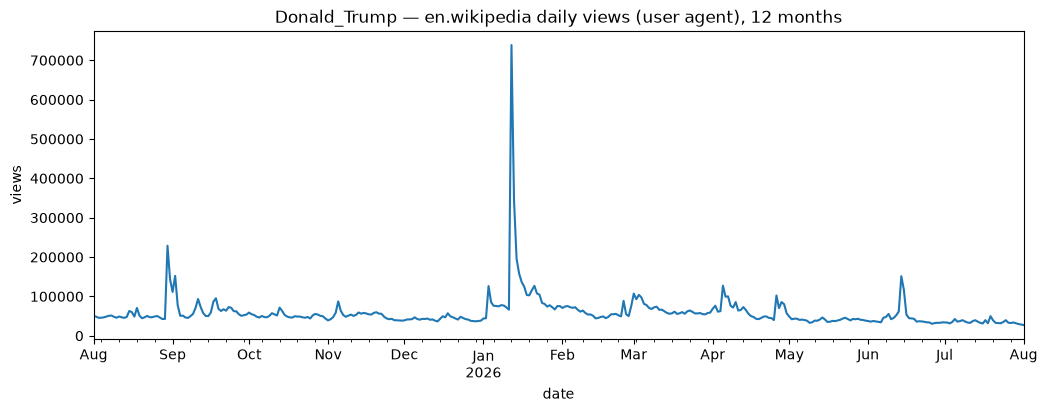

count       366.000000
mean      58912.202186
std       45687.340508
min       27183.000000
25%       42006.250000
50%       49601.000000
75%       62806.250000
max      738649.000000
Name: views, dtype: float64

top 5 spike days:
date
2026-01-12    738649
2026-01-13    344020
2025-08-30    228706
2026-01-14    195691
2026-01-15    157839
Name: views, dtype: int64


In [22]:
import matplotlib.pyplot as plt

trump_df = pd.DataFrame(trump_views)
trump_df["date"] = pd.to_datetime(trump_df["timestamp"], format="%Y%m%d%H")
trump_df = trump_df.set_index("date")["views"]

fig, ax = plt.subplots(figsize=(12, 4))
trump_df.plot(ax=ax)
ax.set_title("Donald_Trump — en.wikipedia daily views (user agent), 12 months")
ax.set_ylabel("views")
plt.show()

print(trump_df.describe())
print("\ntop 5 spike days:")
print(trump_df.sort_values(ascending=False).head())